<a href="https://colab.research.google.com/github/omermohd327-svg/Loan-Approval-Predictor/blob/main/Loan_Approval_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import neccesary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
# Read CSV file
df = pd.read_csv("/2) loan approval data.csv")

In [ ]:
# Perform EDA
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,0
Applicant_ID,50
Applicant_Income,50
Coapplicant_Income,50
Employment_Status,50
Age,50
Marital_Status,50
Dependents,50
Credit_Score,50
Existing_Loans,50
DTI_Ratio,50


In [ ]:
cat_col = df.select_dtypes(include=["object"]).columns
num_col = df.select_dtypes(include=["number"]).columns


In [ ]:
# Handling Missing Data
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[num_col] = num_imp.fit_transform(df[num_col])

col_imp = SimpleImputer(strategy="most_frequent")
df[cat_col] = col_imp.fit_transform(df[cat_col])

Text(0.5, 1.0, 'Is Loan Approved or not ?')

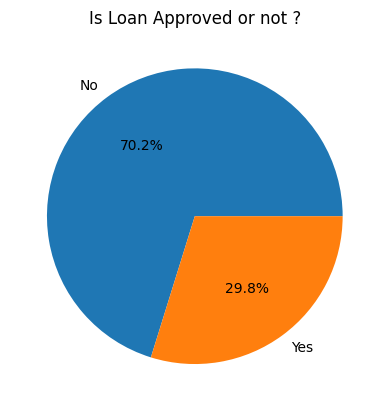

In [ ]:
# Visulaizing Data (EDA)
classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels=["No","Yes"], autopct="%1.1f%%")
plt.title("Is Loan Approved or not ?")

<Axes: xlabel='Loan_Approved', ylabel='Savings'>

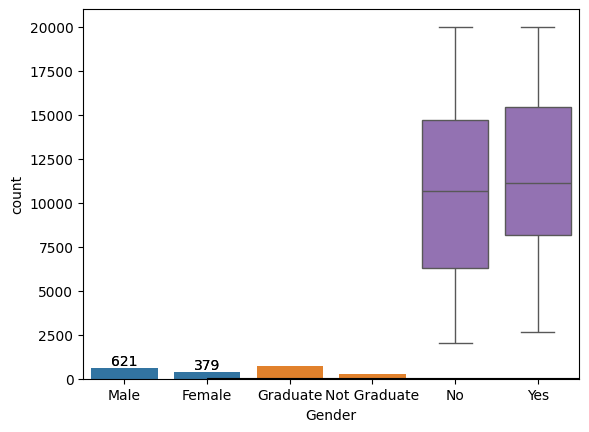

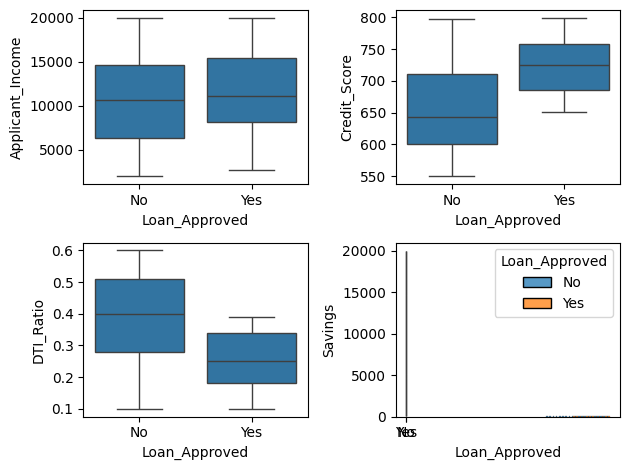

In [ ]:
gender_cat = df["Gender"].value_counts()
ax = sns.barplot(gender_cat)
ax.bar_label(ax.containers[0])

edu_cat = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cat)
ax.bar_label(ax.containers[0])

sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins = 20
 )

sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins = 20
)

sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

fig,axes = plt.subplots(2,2)
sns.boxplot(ax=axes[0,0], data = df, x = "Loan_Approved", y = "Applicant_Income")
sns.boxplot(ax=axes[0,1], data = df, x = "Loan_Approved", y = "Credit_Score")
sns.boxplot(ax=axes[1,0], data = df, x = "Loan_Approved", y = "DTI_Ratio")
sns.boxplot(ax=axes[1,1], data = df, x = "Loan_Approved", y = "Savings")

plt.tight_layout()

sns.histplot(
    data=df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple = "dodge"
)


In [ ]:
# Remove Unecessary Features
df = df.drop("Applicant_ID", axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [ ]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [ ]:
# Encoding
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

# Label Encoding
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

# One HotEncoding
cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
ohe = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded, columns= ohe.get_feature_names_out(cols),index=df.index)
df = pd.concat([df.drop(columns=cols),encoded_df], axis=1)

In [ ]:
# encoded_df.head()
# ohe.get_feature_names_out(cols)
# df.head()
# corr_mat = num_col.corr()

<Axes: >

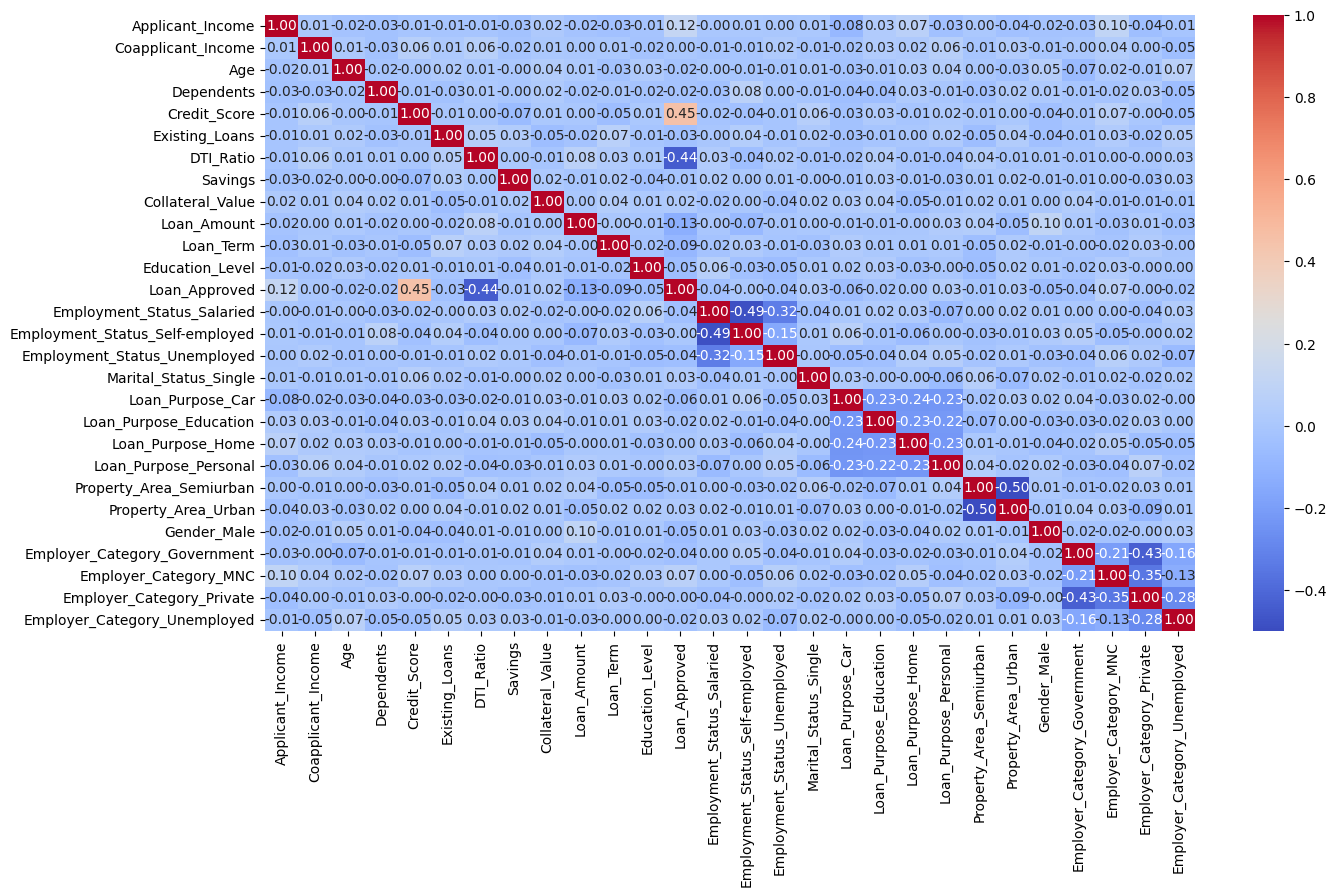

In [ ]:
#Corelation HeatMap
num_cols = df.select_dtypes(include="number")
corr_mat = num_cols.corr()
# num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

plt.figure(figsize=(15,8))
sns.heatmap(
    corr_mat,
    annot=True,
    fmt='.2f',
    cmap="coolwarm"
)

In [ ]:
# Train Test Split

X = df.drop("Loan_Approved",axis=1)
y = df["Loan_Approved"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# X_test.head()

In [ ]:
# Scaling using Standard Scaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,confusion_matrix,accuracy_score,recall_score,f1_score


log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model")
print("Precision:", precision_score(y_test,y_pred)*100,"%" )
print("Recall:", recall_score(y_test,y_pred)*100,"%" )
print("F1 Score:", f1_score(y_test,y_pred)*100,"%" )
print("Accuracy:", accuracy_score(y_test,y_pred)*100,"%" )
print("Confusion Matrix:", confusion_matrix(y_test,y_pred)*100,"%" )

Logistic Regression Model
Precision: 78.33333333333333 %
Recall: 77.04918032786885 %
F1 Score: 77.68595041322314 %
Accuracy: 86.5 %
Confusion Matrix: [[12600  1300]
 [ 1400  4700]] %


In [ ]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

gnb_model = GaussianNB()
gnb_model.fit(X_train_scaled, y_train)
y_pred = gnb_model.predict(X_test_scaled)

# Evaluation
print(" Naive Bayes Model")
print("Precision:", precision_score(y_test,y_pred)*100,"%" )
print("Recall:", recall_score(y_test,y_pred)*100,"%" )
print("F1 Score:", f1_score(y_test,y_pred)*100,"%" )
print("Accuracy:", accuracy_score(y_test,y_pred)*100,"%" )
print("Confusion Matrix:", confusion_matrix(y_test,y_pred)*100,"%" )


 Naive Bayes Model
Precision: 80.35714285714286 %
Recall: 73.77049180327869 %
F1 Score: 76.92307692307693 %
Accuracy: 86.5 %
Confusion Matrix: [[12800  1100]
 [ 1600  4500]] %


In [ ]:
# KNN Classifier

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=13)
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

# Evaluation
print("KNN Classifier Model")
print("Precision:", precision_score(y_test,y_pred)*100,"%" )
print("Recall:", recall_score(y_test,y_pred)*100,"%"  )
print("F1 Score:", f1_score(y_test,y_pred)*100,"%"  )
print("Accuracy:", accuracy_score(y_test,y_pred)*100,"%"  )
print("Confusion Matrix:", confusion_matrix(y_test,y_pred) *100,"%" )

KNN Classifier Model
Precision: 73.17073170731707 %
Recall: 49.18032786885246 %
F1 Score: 58.82352941176471 %
Accuracy: 79.0 %
Confusion Matrix: [[12800  1100]
 [ 3100  3000]] %
